# EDA: AI Pricing Service

Ноутбук воспроизводит анализ набора `synthetic-pricing-v1-seed-42`, который используется для обучения `model_v1`. Данные создаются тем же генератором, что и в `scripts/train_model.py`.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

from train_model import generate_dataset  # noqa: E402

data = generate_dataset(seed=42, rows=1000)
len(data), data[0]

(1000,
 {'product_id': 'ELEC-100500',
  'horizon_days': 1,
  'current_base_price': 2257.26,
  'is_weekend': False,
  'demand_units': 30})

In [2]:
numeric = {
    name: np.array([row[name] for row in data], dtype=float)
    for name in ('horizon_days', 'current_base_price', 'demand_units')
}

summary = {
    name: {
        'min': float(values.min()),
        'max': float(values.max()),
        'mean': round(float(values.mean()), 4),
        'median': float(np.median(values)),
    }
    for name, values in numeric.items()
}
summary['rows'] = len(data)
summary['products'] = Counter(row['product_id'] for row in data)
summary['weekend'] = Counter(row['is_weekend'] for row in data)
summary

{'horizon_days': {'min': 1.0, 'max': 14.0, 'mean': 7.708, 'median': 8.0},
 'current_base_price': {'min': 703.07,
  'max': 2798.68,
  'mean': 1733.3878,
  'median': 1718.7350000000001},
 'demand_units': {'min': 11.0, 'max': 79.0, 'mean': 31.826, 'median': 29.0},
 'rows': 1000,
 'products': Counter({'BOOK-777000': 209,
          'HOME-001200': 203,
          'SPORT-420000': 199,
          'ELEC-200100': 197,
          'ELEC-100500': 192}),
 'weekend': Counter({False: 668, True: 332})}

In [3]:
assert len(data) == 1000
assert all(1 <= row['horizon_days'] <= 14 for row in data)
assert all(row['current_base_price'] > 0 for row in data)
assert all(row['demand_units'] > 0 for row in data)
assert not any(value is None for row in data for value in row.values())
assert len({row['product_id'] for row in data}) == 5
print('Dataset contract checks passed')

Dataset contract checks passed


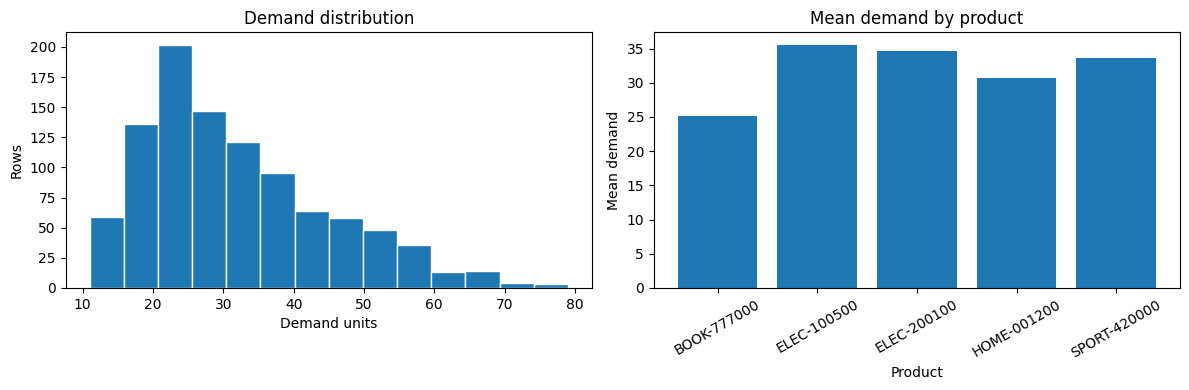

In [4]:
products = sorted({row['product_id'] for row in data})
mean_demand = [
    np.mean([row['demand_units'] for row in data if row['product_id'] == product])
    for product in products
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(numeric['demand_units'], bins=14, edgecolor='white')
axes[0].set(title='Demand distribution', xlabel='Demand units', ylabel='Rows')
axes[1].bar(products, mean_demand)
axes[1].set(title='Mean demand by product', xlabel='Product', ylabel='Mean demand')
axes[1].tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

In [5]:
comparison_path = ROOT / 'reports' / 'model_comparison.json'
comparison = json.loads(comparison_path.read_text(encoding='utf-8'))
comparison['metrics']

{'DummyRegressor': {'mae': 11.0784, 'rmse': 13.4425},
 'LinearRegression': {'mae': 2.9439, 'rmse': 3.8456},
 'DecisionTreeRegressor': {'mae': 2.8489, 'rmse': 3.6965},
 'RandomForestRegressor': {'mae': 2.324, 'rmse': 2.957}}

## Выводы

- Набор содержит 1000 полных наблюдений по пяти товарам.
- Горизонт, цена и целевая переменная находятся в ожидаемых диапазонах.
- Категории товаров представлены близким числом наблюдений.
- Спрос имеет правостороннее распределение и различается между товарами.
- RandomForestRegressor показывает лучшие MAE и RMSE среди сохраненных экспериментов.